In [58]:
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt

In [59]:
df = pd.read_csv("/home/cmp/Documents/Github/Stoner-SCF/out/find_gs.csv")
df = df[np.abs(df['Energy']) > 1e-3]
df = df.sort_values(by="Energy", ascending=True)
df.columns = df.columns.str.strip()

orbitals = ["yz", "zx", "xy"]
spins = ["up", "down"]
layers = [1, 2]
moment_labels = ["Lx", "Ly", "Lz", "L110", "Sx", "Sy", "Sz", "S110"]

# --- Formatted text summaries ---

def mag_angles(x, y, z):
    mag = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z / mag) if mag != 0 else 0.0
    phi = np.arctan2(y, x)
    return mag, theta/np.pi, phi/np.pi

def mag_angles_row(row, layer):
    Lmag, Ltheta, Lphi =  mag_angles(row[f"{layer}_Lx"], row[f"{layer}_Ly"], row[f"{layer}_Lz"])
    Smag, Stheta, Sphi =  mag_angles(row[f"{layer}_Sx"], row[f"{layer}_Sy"], row[f"{layer}_Sz"])
    return Lmag, Ltheta, Lphi, Smag, Stheta, Sphi

def occupation_table(row):
    data = {}
    for layer in layers:
        for spin in spins:
            data[f"L{layer} {spin}"] = [row[f"occ{layer}_{orb}_{spin}"] for orb in orbitals]
    t = pd.DataFrame(data, index=orbitals)
    t["L1 tot"] = t["L1 up"] + t["L1 down"]
    t["L2 tot"] = t["L2 up"] + t["L2 down"]
    t.loc["Total"] = t.sum()
    return t

def moment_table(row):
    data = {
        "Layer 1": [row[f"O1_{lab}"] for lab in moment_labels],
        "Layer 2": [row[f"O2_{lab}"] for lab in moment_labels],
    }
    return pd.DataFrame(data, index=moment_labels)


def add_momentum_angles(row):
    row["O1_Lmag"], row["O1_Ltheta"], row["O1_Lphi"], row["O1_Smag"], row["O1_Stheta"], row["O1_Sphi"] = mag_angles_row(row, "O1")
    row["O2_Lmag"], row["O2_Ltheta"], row["O2_Lphi"], row["O2_Smag"], row["O2_Stheta"], row["O2_Sphi"] = mag_angles_row(row, "O2")
    return row

def print_seed_summary(row):
    print(f"\n===== Seed {int(row['Seed'])}  "
            f"(E = {row['Energy']:.6f}, Threshold = {row['Threshold']:.1e}, "
            f"Rho2Trace = {row['Rho2Trace']:.6f}) =====")
    print("\nOccupations:")
    print(occupation_table(row).round(4).to_string())
    print("\nOrbital (L) and spin (S) moments:")
    print(moment_table(row).round(4).to_string())   
    print(pd.DataFrame([mag_angles_row(row, "O1")], columns=["Lmag", "Ltheta", "Lphi", "Smag", "Stheta", "Sphi"]).round(4).to_string(index=False))
    print(pd.DataFrame([mag_angles_row(row, "O2")], columns=["Lmag", "Ltheta", "Lphi", "Smag", "Stheta", "Sphi"]).round(4).to_string(index=False))


In [60]:
print_seed_summary(df.iloc[0])


===== Seed 3  (E = 25.982770, Threshold = 1.0e-02, Rho2Trace = 8.003206) =====

Occupations:
        L1 up  L1 down   L2 up  L2 down  L1 tot  L2 tot
yz     0.9999   0.5847  1.0000   0.1087  1.5845  1.1087
zx     0.9999   0.5849  1.0000   0.1496  1.5848  1.1496
xy     1.0000   0.1105  0.9998   0.9620  1.1105  1.9618
Total  2.9998   1.2801  2.9998   1.2203  4.2799  4.2201

Orbital (L) and spin (S) moments:
      Layer 1  Layer 2
Lx     0.0449   0.3491
Ly    -0.0269   0.0181
Lz     0.0258  -0.0001
L110   0.0127   0.2596
Sx    -0.0011   0.0004
Sy    -0.0000  -0.0004
Sz     0.8598   0.8897
S110  -0.0008  -0.0000
  Lmag  Ltheta    Lphi   Smag  Stheta    Sphi
0.0584  0.3543 -0.1718 0.8598  0.0004 -0.9855
  Lmag  Ltheta   Lphi   Smag  Stheta    Sphi
0.3495  0.5001 0.0165 0.8897  0.0002 -0.2539


In [61]:
# Ground state data set
df_gs = df[df['Threshold'] <= 1e-1]
#df_gs = df_gs[np.abs(df_gs['Energy'] - df_gs['Energy'].min()) <= 1e-7]
#df_gs = df_gs.apply(add_momentum_angles, axis=1)

In [62]:
import ipywidgets as widgets
from IPython.display import display, clear_output

idx = {'i': 0}
out = widgets.Output()

def show():
    with out:
        clear_output(wait=True)
        print(f"[{idx['i']+1}/{len(df)}]\n")
        print_seed_summary(df_gs.iloc[idx['i']])

def on_prev(b):
    idx['i'] = max(0, idx['i'] - 1)
    show()

def on_next(b):
    idx['i'] = min(len(df_gs) - 1, idx['i'] + 1)
    show()

prev_btn = widgets.Button(description="◀ Prev")
next_btn = widgets.Button(description="Next ▶")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

display(widgets.HBox([prev_btn, next_btn]), out)
show()

Output()

KeyError: 'O1_Ltheta'

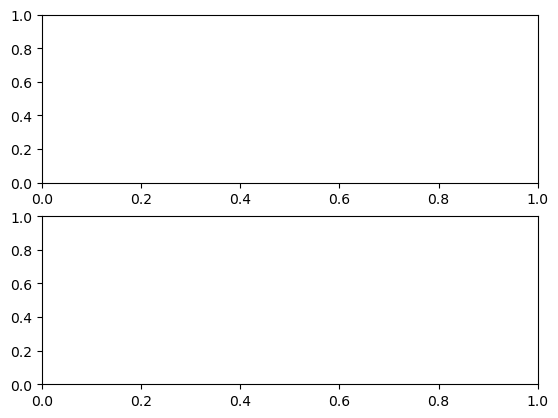

In [63]:
fig, axs = plt.subplots(2, 1)

# phi is the angular coordinate, theta is the radial coordinate
theta = df_gs["O1_Ltheta"]   # or Stheta, in radians
phi = df_gs["O1_Lphi"]       # in radians

sc_phi = axs[0].scatter(
    phi,df_gs.index,
    s=80,
    c="blue",
    linewidth=0.5,
    alpha=0.9,
)

sc_theta = axs[0].scatter(
    theta,df_gs.index,
    s=80,
    c="red",
    linewidth=0.5,
    alpha=0.9,
)

axs[0].set_xlabel("Angle $\\pi$")
axs[0].set_ylabel("Index")
axs[0].legend([sc_phi, sc_theta], ["Phi", "Theta"])
plt.tight_layout()

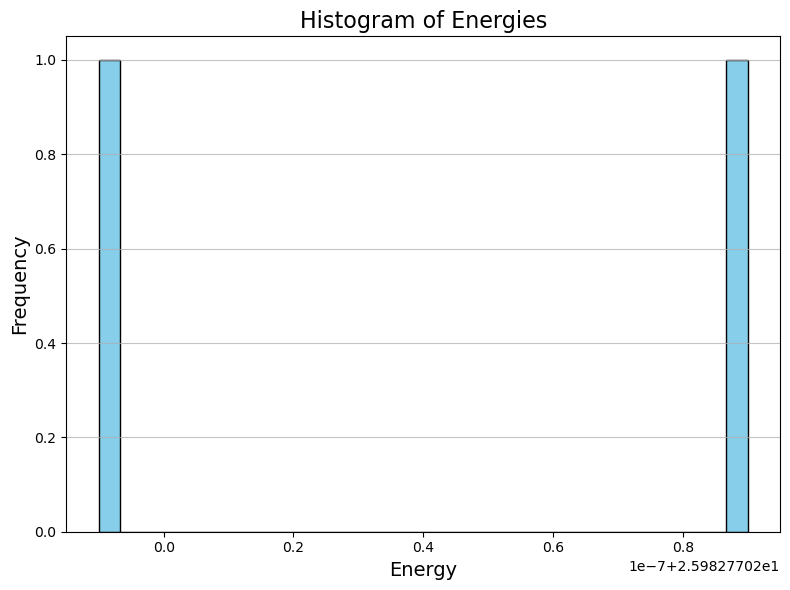

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(df['Energy'], bins=30, color='skyblue', edgecolor='black')

ax.set_title('Histogram of Energies', fontsize=16)
ax.set_xlabel('Energy', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()

/tmp/ipykernel_885926/1917668191.py:9: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


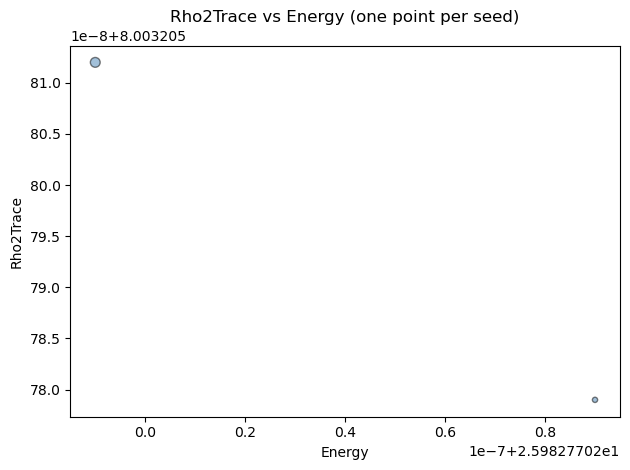

In [ ]:
colors = np.where(df["Seed"] < 0, "red", "steelblue")
sizes = 100 * -1/np.log10(df["Threshold"])

fig, ax = plt.subplots()

neg = df["Seed"] < 0
pos = ~neg

ax.scatter(
    df["Energy"][neg], df["Rho2Trace"][neg],
    s=sizes[neg], alpha=1, marker="x",
    edgecolor="black", linewidth=1, color="red",
)
ax.scatter(
    df["Energy"][pos], df["Rho2Trace"][pos],
    s=sizes[pos], alpha=0.5, marker="o",
    edgecolor="black", linewidth=1, color="steelblue",
)

ax.set_xlabel("Energy")
ax.set_ylabel("Rho2Trace")
ax.set_title("Rho2Trace vs Energy (one point per seed)")

plt.tight_layout()
plt.savefig("energy_vs_rho2trace_scatter.png", dpi=150)
plt.show()

In [ ]:
df_sort_tresh = df.sort_values(by="Threshold", ascending=True)
print(df_sort_tresh.iloc[11]['Energy'])
print(df_sort_tresh.iloc[0]['Energy'])
print(df_sort_tresh.iloc[1]['Energy'] - df_sort_tresh.iloc[0]['Energy'])

IndexError: single positional indexer is out-of-bounds

In [ ]:
def analyze_output(ffolder, fpath):
    df = pd.read_csv(ffolder + fpath)
    # Filtered Unconverged
    df = df[np.abs(df['Energy']) > 1e-3]

    n_bins = 5
    df['energy_bin'] = pd.cut(df['Energy'], bins=n_bins)

    # Count how many fall in each bin
    counts = df['energy_bin'].value_counts().sort_index()

    # Count just the lowest energy bin
    lowest_bin_count = counts.iloc[0]
    total_count = len(df)
    lowest_energy = df['Energy'].min()

    return lowest_energy, lowest_bin_count, total_count

def returnMCA(ffolder):
    rows = []
    for N in [9.0, 9.25, 9.5, 9.75, 10.0, 10.25, 10.5, 10.75, 11.0, 11.25, 11.5]:
        for spin_dir in ["001", "110"]:
            fpath = f"/{spin_dir}gsoutN={N}.csv"
            lnE, lnBinLowest, totCount = analyze_output(ffolder, fpath)
            rows.append({
                'N': N,
                'spin_dir': spin_dir,
                'LowestEnergy': lnE,
                'LowestBinCount': lnBinLowest,
                'TotalCount': totCount
            })
    dfMCA = pd.DataFrame(rows)
    return dfMCA

def computeMCAList(ffolder):
    dfMCA = returnMCA(ffolder)
    
    MCA = []
    for N in sorted(dfMCA['N'].unique()):
        e001 = dfMCA.loc[(dfMCA['N'] == N) & (dfMCA['spin_dir'] == "001"), 'LowestEnergy'].values[0]
        e110 = dfMCA.loc[(dfMCA['N'] == N) & (dfMCA['spin_dir'] == "110"), 'LowestEnergy'].values[0]
        MCA.append(e001 - e110)
    
    return MCA


ffolder = "/home/cmp/Documents/Github/Stoner-SCF/out/sweeps/NoSOCNsweep"
dfMCA = returnMCA(ffolder)

MCAList = computeMCAList(ffolder)

dfMCA

FileNotFoundError: [Errno 2] No such file or directory: '/home/cmp/Documents/Github/Stoner-SCF/out/sweeps/NoSOCNsweep/001gsoutN=9.25.csv'

In [ ]:
MCAList

[np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(-6.379999994976515e-06),
 np.float64(-0.0016278300000038826),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

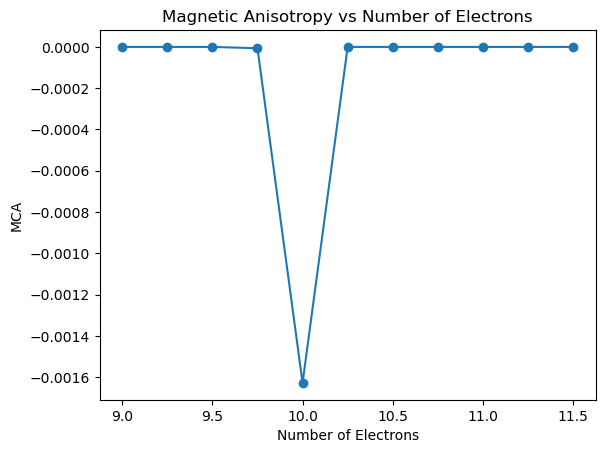

In [ ]:
fig, ax = plt.subplots()

nelectron = [9.0, 9.25, 9.5, 9.75, 10.0, 10.25, 10.5, 10.75, 11.0, 11.25, 11.5]
ax.plot(nelectron, MCAList, marker='o')
ax.set_xlabel('Number of Electrons')
ax.set_ylabel('MCA')
ax.set_title('Magnetic Anisotropy vs Number of Electrons')
plt.show()